(980, 905, 4)


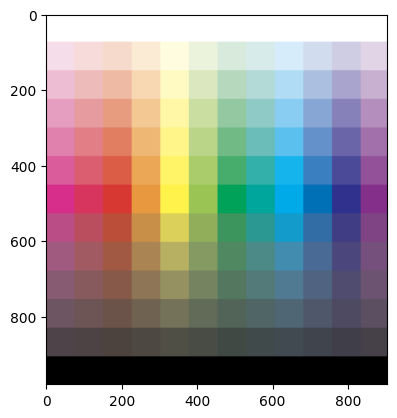

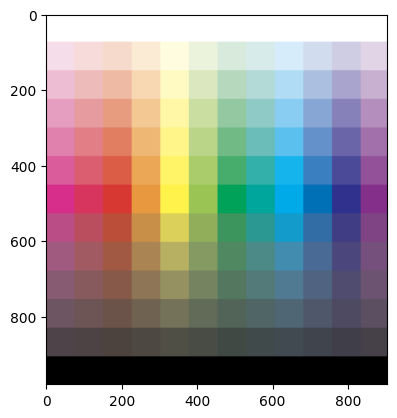

(<Figure size 640x480 with 1 Axes>,
 None)

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color

img = io.imread('../BlackColourWhite.png')
print(np.shape(img)) # (980, 905, 4)
plt.figure(), plt.imshow(img), plt.show()

img = img[:, :, 0:3]
plt.figure(), plt.imshow(img), plt.show()


In [9]:
hsv = color.rgb2hsv(img)
print(type(hsv))
print(np.shape(hsv))
print(type(hsv[0,0,0]))

<class 'numpy.ndarray'>
(980, 905, 3)
<class 'numpy.float64'>


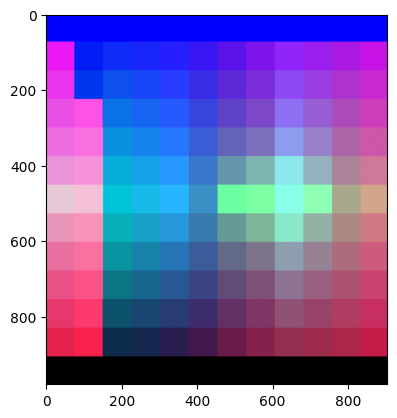

(<Figure size 640x480 with 1 Axes>,
 None)

In [10]:
plt.figure(), plt.imshow(hsv), plt.show()
# imshow mdoar pentru RGB; nu stie sa afiseze HSV
# imshow foloseste uint8 si floate intre (0, 1)
# plt.imshow(hsv) => toate valorile au fost convertite intre 0 si 1

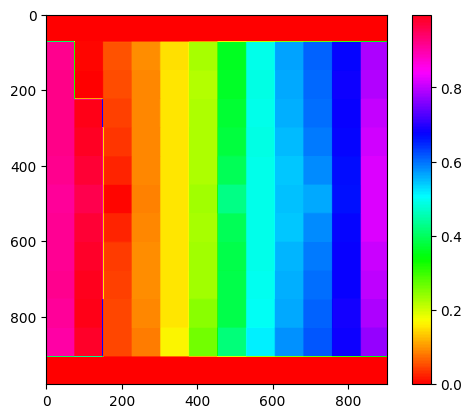

(<Figure size 640x480 with 2 Axes>,
 None)

In [14]:
H = hsv[:, :, 0]
S = hsv[:, :, 1]
V = hsv[:, :, 2]
plt.figure(), plt.imshow(H, cmap='hsv'), plt.colorbar(), plt.show()

# trebuie sa specificam color map pentru ca i-am dat o matrice scalara
# colormap default: viridis

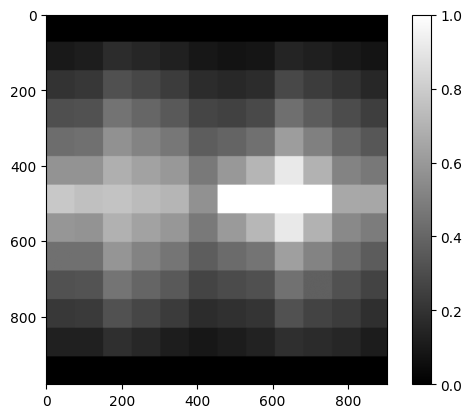

(<Figure size 640x480 with 2 Axes>,
 None)

In [17]:
plt.figure(), plt.imshow(S, cmap='grey'), plt.colorbar(), plt.show()

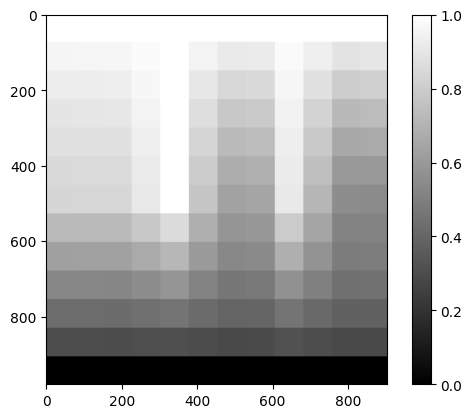

(<Figure size 640x480 with 2 Axes>,
 None)

In [18]:
plt.figure(), plt.imshow(V, cmap='grey'), plt.colorbar(), plt.show()

0.3268073863636364 1.0 1.0


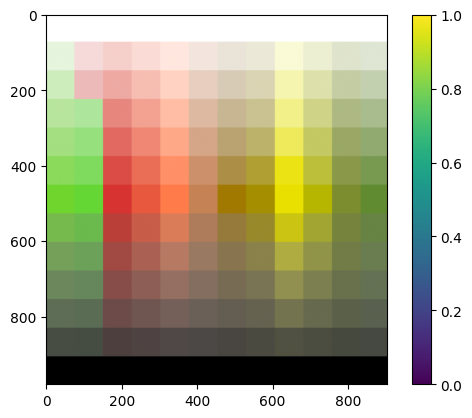

(<Figure size 640x480 with 2 Axes>,
 None)

In [28]:
print(np.max(H), np.max(S), np.max(V))

HH = H * 0.9  # schimbare subtila de Hue (0.5 - schimbare mare)
hsv[:, :, 0] = HH
rgb = color.hsv2rgb(hsv)
plt.figure(), plt.imshow(rgb), plt.colorbar(), plt.show()


In [29]:
# lab - cromaticitate uniforma - poate fi calibrat cu ajutorul unui alb de referinta
# => illuminant='D65' - lumina de zi - default
# observer='2' - 2 grade default; se mai foloseste si 10

lab = color.rgb2lab(img)
print(type(lab[0, 0, 0]))

<class 'numpy.float64'>


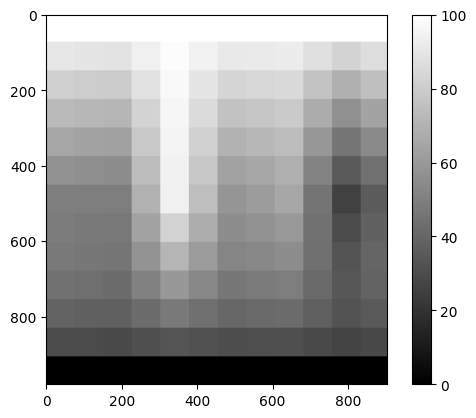

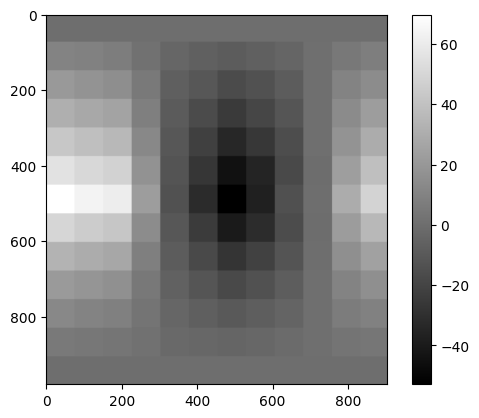

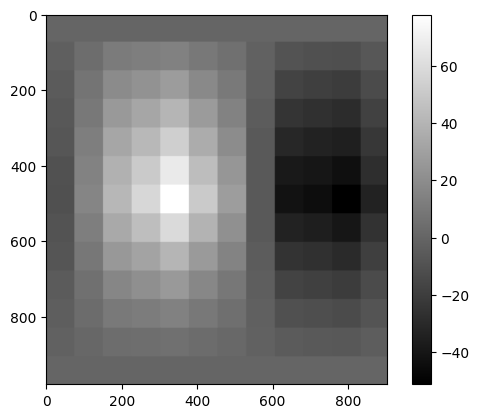

(<Figure size 640x480 with 2 Axes>,
 None)

In [32]:
l = lab[:, :, 0]
a = lab[:, :, 1]
b = lab[:, :, 2]

# luminanta
plt.figure(), plt.imshow(l, cmap='grey'), plt.colorbar(), plt.show()

# a - diferenta intre rosu si verde
# pe partea pozitiva marcheaza rosu, pe partea negativa marcheaza verde
# a = 0 => culori acromatice corespunzatoare lui L
plt.figure(), plt.imshow(a, cmap='grey'), plt.colorbar(), plt.show()

# b - diferenta dintre galben si albastru
# pe partea pozitiva marcheaza galben, pe partea negativa marcheaza albastru
plt.figure(), plt.imshow(b, cmap='grey'), plt.colorbar(), plt.show()



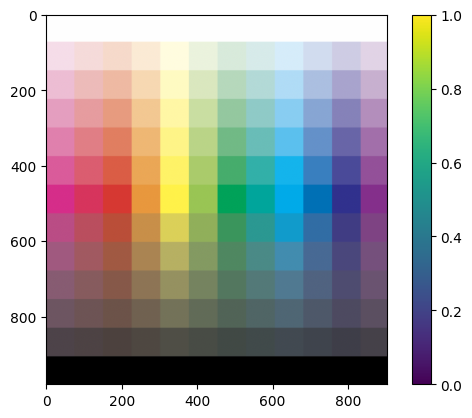

Maxim din planul RGB:  0.9999999999999999


In [35]:
# am schimbat rosu cu verde si galben cu albastru
lab[:,:,1] = -a
lab[:,:,2] = -b
rgb = color.lab2rgb(lab)
plt.figure(), plt.imshow(rgb), plt.colorbar(), plt.show()

print("Maxim din planul RGB: ", np.max(rgb[:,:,1]))

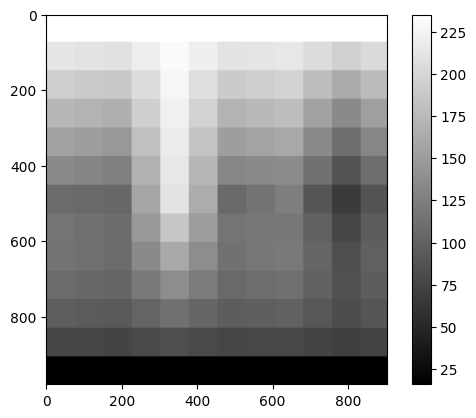

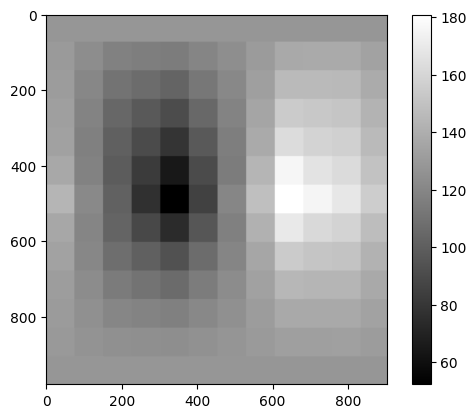

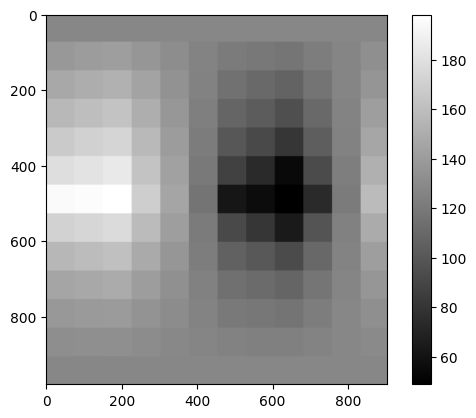

(<Figure size 640x480 with 2 Axes>,
 None)

In [38]:
ycbcr = color.rgb2ycbcr(img)
y = ycbcr[:,:,0] # luminanta
cb = ycbcr[:,:,1] # dif intre nuante de albastru
cr = ycbcr[:,:,2] # dif intre nuante de rosu

# luminanta
plt.figure(), plt.imshow(y, cmap="gray"), plt.colorbar(), plt.show()

# dif intre nuante de albastru
plt.figure(), plt.imshow(cb, cmap="gray"), plt.colorbar(), plt.show()

# dif intre nuante de rosu
plt.figure(), plt.imshow(cr, cmap="gray"), plt.colorbar(), plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


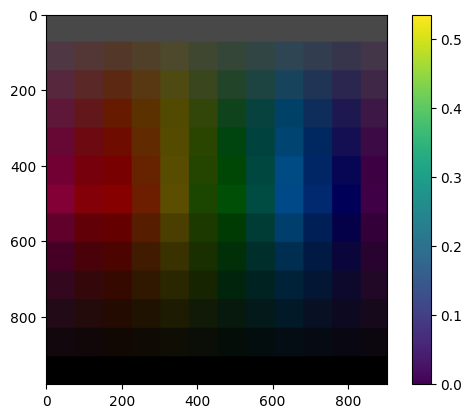

(<Figure size 640x480 with 2 Axes>,
 None)

In [39]:
ycbcr[:,:,0] = y / 3 # am redus intensitatea luminoasa de 3 ori
rgb = color.ycbcr2rgb(ycbcr)
plt.figure(), plt.imshow(rgb), plt.colorbar(), plt.show()